In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from neuralnet import avg_fidelity_loss, avg_norm_loss 
import math
import cv2

from dataGenNew import generate_random_function, Ugen, rand_En, rand_costheta, rand_phi, full_measure

import tensorflow as tf
import time 

Model: "spiffyfaf"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 5  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 128, 128, 32  1536        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 64, 64, 32)   0           ['sequential[0][0]']             
                                                                                          

# Load experimental data

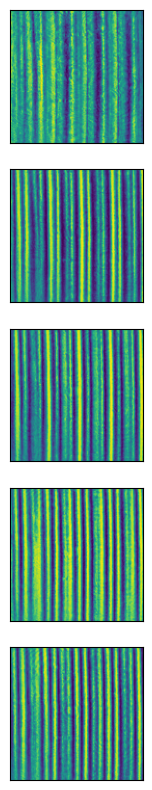

In [54]:
## Names of processes ##
# Tx(pi)WTx(pi2)WTx(pi2)
# Tx(pi)
# Ty(pi2)Tx(pi2)W
# S1x(pi)W
# S2x(pi)WS1y(pi)

process_num = 4
process_list = {1:"Tx(pi)", 2:"Ty(pi2)Tx(pi2)W", 3:"Tx(pi)WTx(pi2)WTx(pi2)", 4:"S1x(pi)W", 5:"S2x(pi)WS1y(pi)"}

process_unnamed = process_list[process_num]
process = "/" + process_unnamed

num_pix = 128
path = "experimental_data"

LL = np.loadtxt(path+process+f"/LL{num_pix}.txt")
LH = np.loadtxt(path+process+f"/LH{num_pix}.txt")
LD = np.loadtxt(path+process+f"/LD{num_pix}.txt")
HH = np.loadtxt(path+process+f"/HH{num_pix}.txt")
HD = np.loadtxt(path+process+f"/HD{num_pix}.txt")





# Create matrix for measurements 

X = np.zeros([num_pix,num_pix,5])
X[:,:,0] = LL
X[:,:,1] = LH
X[:,:,2] = LD
X[:,:,3] = HH
X[:,:,4] = HD

# We can plot these, I guess

fig, ax = plt.subplots(5,1, figsize=(2,10))


ax[0].imshow(X[:,:,0]) 
ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].imshow(X[:,:,1]) 
ax[1].get_xaxis().set_visible(False)
ax[1].get_yaxis().set_visible(False)

ax[2].imshow(X[:,:,2]) 
ax[2].get_xaxis().set_visible(False)
ax[2].get_yaxis().set_visible(False)

ax[3].imshow(X[:,:,3])
ax[3].get_xaxis().set_visible(False)
ax[3].get_yaxis().set_visible(False)

ax[4].imshow(X[:,:,4])
ax[4].get_xaxis().set_visible(False)
ax[4].get_yaxis().set_visible(False)


# Load the trained neural network

In [55]:
# Load model checkpoint 

mol_64 = 'network64_30'
mol_128 = 'network128_8batch'
mol_128_16 = 'network128_16batch'

loaded_model = tf.keras.models.load_model(mol_128_16, custom_objects={'math': math, 'minMean': avg_fidelity_loss, 'minMeanNormal':avg_norm_loss}, compile=True)

# Prompt the network to make predictions and perform unitary matrix reconstruction

In [56]:
full_meas_enhance = tf.expand_dims(X, axis=0)

# Initiate predictions
start_time = time.time()
y_pred=loaded_model.predict(full_meas_enhance)
fin_time = time.time() - start_time
print(fin_time)
np.shape(y_pred)

En_vect = y_pred[0,:,:,0]
nx_vect = np.sin(y_pred[0,:,:,1])*np.cos(y_pred[0,:,:,2])
ny_vect = np.sin(y_pred[0,:,:,1])*np.sin(y_pred[0,:,:,2])
nz_vect = np.cos(y_pred[0,:,:,1])

1/1 [==============================] - 1s 1s/step
1.3098185062408447


# Plot the reconstructions

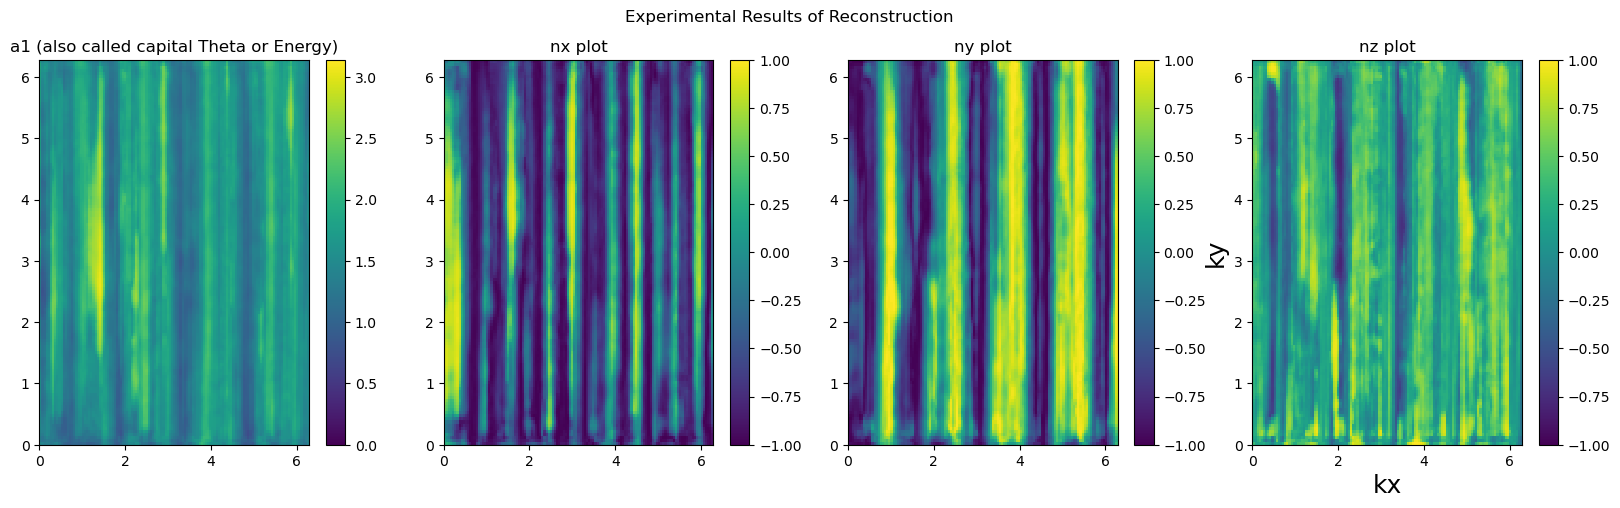

In [57]:
# Transpose the matrix

En_vect_t = np.transpose(En_vect)
nx_vect_t = np.transpose(nx_vect)
ny_vect_t = np.transpose(ny_vect)
nz_vect_t = np.transpose(nz_vect)

# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Experimental Results of Reconstruction')

c = ax[0].pcolormesh(x, y, En_vect_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_vect_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_vect_t[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_vect_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'experimental_{num_pix}' + process_unnamed + '.png')

In [58]:
# To compare, let's also consider the theoretical data 
path = f"theoretical_data/{num_pix}"
direc = path + process

E_th_mat = np.loadtxt(direc+'/en.txt')
nx_th_mat = np.loadtxt(direc+'/nx.txt')
ny_th_mat = np.loadtxt(direc+'/ny.txt')
nz_th_mat =  np.loadtxt(direc+'/nz.txt')

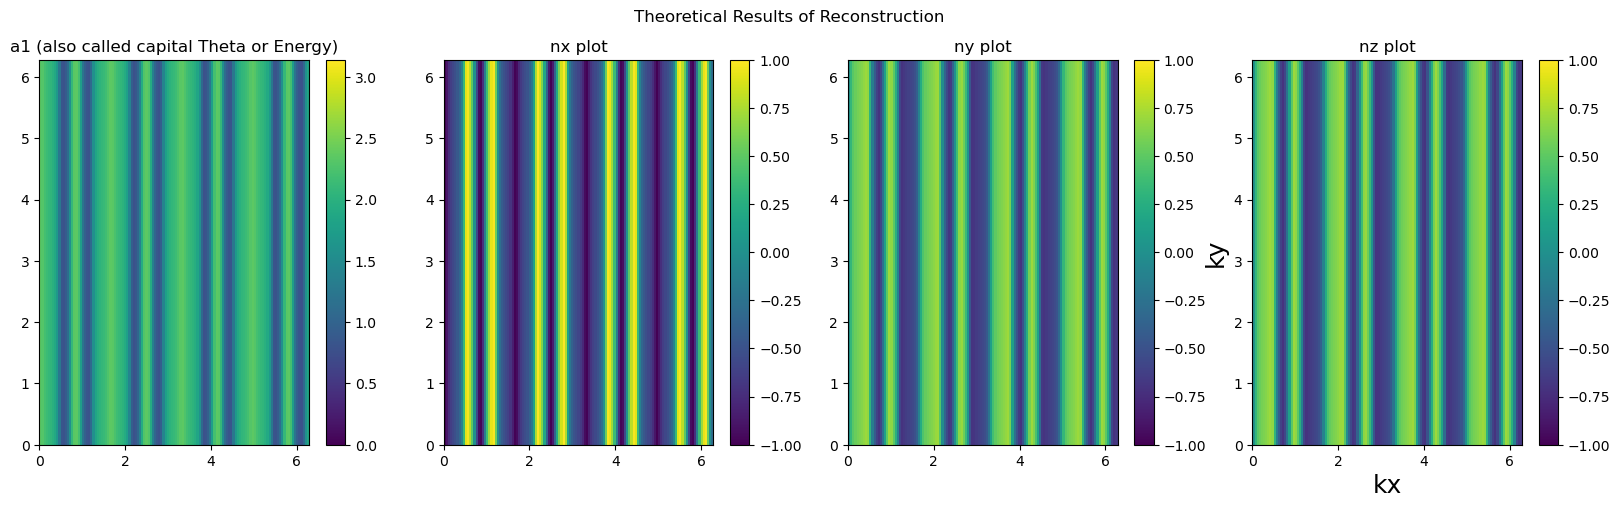

In [59]:
# We can also plot the reconstructions in this case 

# Transpose the matrix

En_th_t = np.transpose(E_th_mat)
nx_th_t = np.transpose(nx_th_mat)
ny_th_t = np.transpose(ny_th_mat)
nz_th_t = np.transpose(nz_th_mat)

# Let's bind the data with some minima and maxima 

minA1 = 0
maxA1 = np.pi

minNx = -1
maxNx = 1

minNy = -1
maxNy = 1

minNz = -1
maxNz = 1

kxvals=np.linspace(0,2*np.pi,num_pix)
kyvals=np.linspace(0,2*np.pi,num_pix)

fig, ax = plt.subplots(1,4,figsize=(20, 5))
y,x=np.meshgrid(kxvals,kyvals)

plt.suptitle('Theoretical Results of Reconstruction')

c = ax[0].pcolormesh(x, y, En_th_t[:-1, :-1], cmap='viridis', vmin=minA1, vmax=maxA1)
ax[0].set_title('a1 (also called capital Theta or Energy)')
# set the limits of the plot to the limits of the data
ax[0].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c, ax=ax[0])

c2 = ax[1].pcolormesh(x, y, nx_th_t[:-1, :-1], cmap='viridis', vmin=minNx, vmax=maxNx)
ax[1].set_title('nx plot')
# set the limits of the plot to the limits of the data
ax[1].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c2, ax=ax[1])

c3 = ax[2].pcolormesh(x, y, ny_th_t[:-1,:-1], cmap='viridis', vmin=minNy, vmax=maxNy)
ax[2].set_title('ny plot')
# set the limits of the plot to the limits of the data
ax[2].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c3, ax=ax[2])

c4 = ax[3].pcolormesh(x, y, nz_th_t[:-1, :-1], cmap='viridis', vmin=minNz, vmax=maxNz)
ax[3].set_title('nz plot')
# set the limits of the plot to the limits of the data
ax[3].axis([x.min(), x.max(), y.min(), y.max()])
plt.xlabel('kx',fontsize=18)
plt.ylabel('ky',fontsize=18)
cbar=fig.colorbar(c4, ax=ax[3])

plt.savefig(f'theoretical_{num_pix}' + process_unnamed + '.png')

# Compute the fidelity ... because we CAN

In [23]:
def fidelity(mat1,mat2):
    prod=np.trace(np.dot(np.conjugate(mat1.T),mat2))
    
    return 0.5*np.abs(prod)

def op_par(En,nx,ny,nz):
    mat=np.zeros([2,2],dtype=complex)
    
    mat[0,0]=np.cos(En) - 1j*np.sin(En)*nz
    mat[0,1]=-1j*np.sin(En)*(nx - 1j*ny)
    mat[1,0]=-1j*np.sin(En)*(nx + 1j*ny)
    mat[1,1]=np.cos(En) + 1j*np.sin(En)*nz
    
    return mat

Fvals=np.zeros([num_pix,num_pix])
for i in range(num_pix):
    for j in range(num_pix):
            netU=op_par(En_vect[i,j],nx_vect[i,j],ny_vect[i,j],nz_vect[i,j])
            thU=op_par(En_th_t[i,j],nx_th_t[i,j],ny_th_t[i,j],nz_th_t[i,j])
            Fvals[i,j]=fidelity(netU,thU)
            
print(np.mean(Fvals))



0.506843662150265
